In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/raghuvirkumawat/clean-data/SALES_DATA_CLEAN.csv


In [5]:
df = pd.read_csv("/kaggle/input/datasets/raghuvirkumawat/clean-data/SALES_DATA_CLEAN.csv" ,sep=";")
df.head()


,SALES_DATE,STORE_ID,PRODUCT_ID,PRODUCT_CATEGORY,REGION,INVENTORY_LEVEL,UNITS_SOLD,UNITS_ORDERED,PRICE,DISCOUNT,WEATHER_CONDITION,PROMOTION,COMPETITOR_PRICING,SEASONALITY,EPIDEMIC,DEMAND
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [6]:
print( "Data Info:",df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SALES_DATE          76000 non-null  object 
 1   STORE_ID            76000 non-null  object 
 2   PRODUCT_ID          76000 non-null  object 
 3   PRODUCT_CATEGORY    76000 non-null  object 
 4   REGION              76000 non-null  object 
 5   INVENTORY_LEVEL     76000 non-null  int64  
 6   UNITS_SOLD          76000 non-null  int64  
 7   UNITS_ORDERED       76000 non-null  int64  
 8   PRICE               76000 non-null  float64
 9   DISCOUNT            76000 non-null  int64  
 10  WEATHER_CONDITION   76000 non-null  object 
 11  PROMOTION           76000 non-null  int64  
 12  COMPETITOR_PRICING  76000 non-null  float64
 13  SEASONALITY         76000 non-null  object 
 14  EPIDEMIC            76000 non-null  int64  
 15  DEMAND              76000 non-null  int64  
dtypes: f

In [7]:
df['SALES_DATE'] = pd.to_datetime(df['SALES_DATE'])

df['year'] = df['SALES_DATE'].dt.year
df['month'] = df['SALES_DATE'].dt.month
df['day'] = df['SALES_DATE'].dt.day
df['day_of_week'] = df['SALES_DATE'].dt.dayofweek

df.head()

,SALES_DATE,STORE_ID,PRODUCT_ID,PRODUCT_CATEGORY,REGION,INVENTORY_LEVEL,UNITS_SOLD,UNITS_ORDERED,PRICE,DISCOUNT,WEATHER_CONDITION,PROMOTION,COMPETITOR_PRICING,SEASONALITY,EPIDEMIC,DEMAND,year,month,day,day_of_week
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,1,5
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,1,5
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,1,5
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,1,5
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,1,5


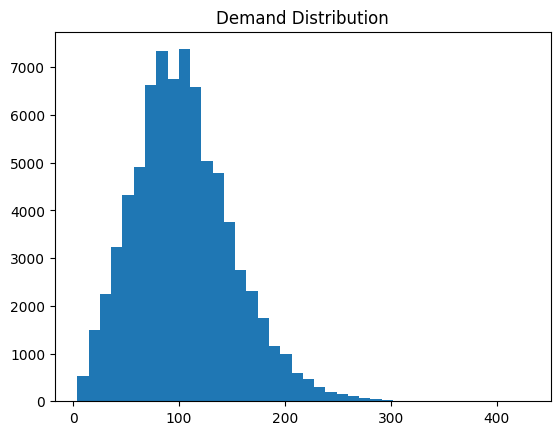

In [8]:
# target distribution
import matplotlib.pyplot as plt

plt.hist(df['DEMAND'], bins=40)
plt.title("Demand Distribution")
plt.show()

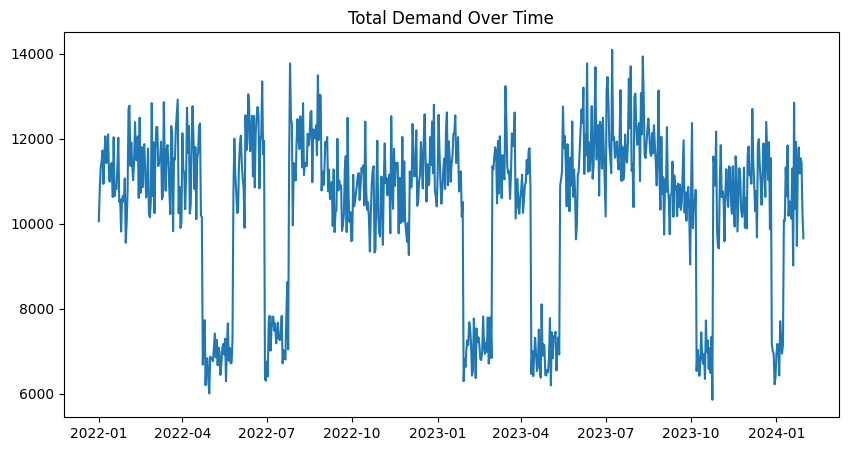

In [9]:
# daily_demand_plot 
daily_demand = df.groupby('SALES_DATE')['DEMAND'].sum()

plt.figure(figsize=(10,5))
plt.plot(daily_demand)
plt.title("Total Demand Over Time")
plt.show()

In [10]:
# feature engineering or creating new features
df = df.sort_values('SALES_DATE')

df = df.sort_values(['STORE_ID','PRODUCT_ID','SALES_DATE'])

df['lag_1'] = df.groupby(['STORE_ID','PRODUCT_ID'])['DEMAND'].shift(1)
df['lag_7'] = df.groupby(['STORE_ID','PRODUCT_ID'])['DEMAND'].shift(7)
df['lag_14'] = df.groupby(['STORE_ID','PRODUCT_ID'])['DEMAND'].shift(14)

df['rolling_mean_7'] = (
    df.groupby(['STORE_ID','PRODUCT_ID'])['DEMAND']
    .transform(lambda x: x.rolling(7).mean())
)

df['rolling_mean_14'] = (
    df.groupby(['STORE_ID','PRODUCT_ID'])['DEMAND']
    .transform(lambda x: x.rolling(14).mean())
)

In [11]:
df.head(10)

,SALES_DATE,STORE_ID,PRODUCT_ID,PRODUCT_CATEGORY,REGION,INVENTORY_LEVEL,UNITS_SOLD,UNITS_ORDERED,PRICE,DISCOUNT,...,DEMAND,year,month,day,day_of_week,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,115,2022,1,1,5,NaN,NaN,NaN,NaN,NaN
100,2022-01-02,S001,P0001,Electronics,North,93,71,0,65.63,5,...,84,2022,1,2,6,115.0,NaN,NaN,NaN,NaN
200,2022-01-03,S001,P0001,Electronics,North,274,142,229,68.55,15,...,132,2022,1,3,0,84.0,NaN,NaN,NaN,NaN
300,2022-01-04,S001,P0001,Electronics,North,132,42,0,61.66,10,...,67,2022,1,4,1,132.0,NaN,NaN,NaN,NaN
400,2022-01-05,S001,P0001,Electronics,North,319,129,0,59.56,25,...,110,2022,1,5,2,67.0,NaN,NaN,NaN,NaN
500,2022-01-06,S001,P0001,Electronics,North,190,98,308,84.03,0,...,146,2022,1,6,3,110.0,NaN,NaN,NaN,NaN
600,2022-01-07,S001,P0001,Electronics,North,92,92,0,66.07,10,...,87,2022,1,7,4,146.0,NaN,NaN,105.857143,NaN
700,2022-01-08,S001,P0001,Electronics,North,308,96,248,68.56,10,...,113,2022,1,8,5,87.0,115.0,NaN,105.571429,NaN
800,2022-01-09,S001,P0001,Electronics,North,212,57,0,62.76,10,...,87,2022,1,9,6,113.0,84.0,NaN,106.000000,NaN
900,2022-01-10,S001,P0001,Electronics,North,403,88,0,68.99,5,...,99,2022,1,10,0,87.0,132.0,NaN,101.285714,NaN


In [19]:
df = pd.get_dummies(df, drop_first=True)
df = df.dropna()
df.shape

(74600, 55)

In [24]:
# applying different models now 

# 1.GRADIENT BOOSTING REGRESSOR
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

# train_data and test_data using train_test_split
from sklearn.model_selection import train_test_split

data_x = df.drop(columns = ['DEMAND', 'SALES_DATE'], axis = 1)
data_y = df['DEMAND']

train_x, test_x, train_y, test_y = train_test_split(data_x, data_y, test_size=0.2, shuffle = False)



In [21]:
# model implentation GBR
model = GradientBoostingRegressor()
model.fit(train_x, train_y) 


GradientBoostingRegressor()

In [26]:
predict_train = model.predict(train_x)
print("target on train data: ", predict_train)

rsquared_on_train = r2_score(train_y, predict_train)
print("R- squared on train dataset: ",rsquared_on_train )

predict_test = model.predict(test_x)
print("target prediction on test data:", predict_test)

rsquared_on_test = r2_score(test_y, predict_test)
print("R- squared on test dataset: ",rsquared_on_test )

target on train data:  [142.10006704 124.24479151  92.26669944 ...  70.74455985  92.11418414
 106.01726047]
R- squared on train dataset:  0.8724229092081901
target prediction on test data: [183.42636844 120.55290027 174.76108564 ... 122.93700297 109.5931829
  74.43667703]
R- squared on train dataset:  0.8687024146251898


In [31]:
# model2. xgboost regressor
# data prep and library import

from sklearn.model_selection import train_test_split
data_x = df.drop(columns = ['DEMAND', 'SALES_DATE'])
data_y = df['DEMAND']

train_x, test_x, train_y, test_y = train_test_split(data_x, data_y, test_size = 0.2, shuffle = False)

from xgboost import XGBRegressor
from sklearn.metrics import r2_score 

In [34]:
# model implementation
model = XGBRegressor(
    n_estimators=100,       # fewer trees
    max_depth=3,            # shallower trees
    learning_rate=0.05,     # slower learning
    subsample=0.8,          # randomly sample rows per tree
    colsample_bytree=0.8,   # randomly sample features per tree
    random_state=42
)
model.fit(train_x, train_y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [35]:
# model prediction and score
print("xgb results\n")
predict_train = model.predict(train_x)
print("predictions on train dataset:", predict_train)

rsquared_on_train = r2_score(train_y, predict_train)
print("R squared value on train dataset: ", rsquared_on_train)

predict_test = model.predict(test_x)
print("predictions on test dataset:", predict_test)

rsquared_on_test = r2_score(test_y, predict_test)
print("R squared value on test dataset: ", rsquared_on_test)




xgb results

predictions on train dataset: [142.68478  114.48443   90.037704 ...  70.56577   90.87688  111.48399 ]
R squared value on train dataset:  0.8540312647819519
predictions on test dataset: [180.96829 120.32247 174.36937 ... 119.2937  109.88203  74.18193]
R squared value on test dataset:  0.8543272614479065


In [36]:
# model 3. Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import r2_score

# data prep
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split(data_x, data_y, test_size = 0.2, shuffle = False)


In [43]:
# model implementation
model = RandomForestRegressor(
    n_estimators=300,       # more trees for stability
    max_depth=15,           # slightly deeper to capture trends
    min_samples_leaf=2,     # prevent overfitting tiny leaves
    max_features='sqrt',    # feature subset per split
    bootstrap=True,         # default, good for generalization
    n_jobs=-1,              # use all cores
    random_state=42
)
model.fit(train_x, train_y)

RandomForestRegressor(max_depth=15, max_features='sqrt', min_samples_leaf=2,
                      n_estimators=300, n_jobs=-1, random_state=42)

In [44]:
# accuracy on model
print("random forest regressor results\n")

predict_train = model.predict(train_x)
print("target on train data: ", predict_train)

rsquared_on_train = r2_score(train_y, predict_train)
print("R- squared on train dataset: ",rsquared_on_train )

predict_test = model.predict(test_x)
print("target prediction on test data:", predict_test)

rsquared_on_test = r2_score(test_y, predict_test)
print("R- squared on test dataset: ",rsquared_on_test )

random forest regressor results

target on train data:  [146.36698716 121.21045948  93.82806988 ...  73.09462281  78.7034198
  91.66361286]
R- squared on train dataset:  0.9132427383100993
target prediction on test data: [161.19149777 122.58731589 166.58362017 ... 113.58949015 105.37487577
  74.2171745 ]
R- squared on train dataset:  0.8461525637686085


In [48]:
# model 4. LightGBM
# model import and dataset

import lightgbm as lgb
from sklearn.metrics import r2_score

# data preparation 
from sklearn.model_selection import train_test_split

data_x = df.drop(columns = ['DEMAND', 'SALES_DATE'], axis = 1)
data_y = df['DEMAND']

train_x, test_x, train_y, test_y = train_test_split(data_x, data_y, test_size=0.2, shuffle = False)



In [58]:
# model implementation
lgb_model = lgb.LGBMRegressor()

lgb_model.fit(train_x, train_y)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004377 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2686
[LightGBM] [Info] Number of data points in the train set: 59680, number of used features: 52
[LightGBM] [Info] Start training from score 103.779792


LGBMRegressor()

In [60]:
# accuracy on model
print("light gradient boosting results\n")

predict_train = lgb_model.predict(train_x)
print("target on train data: ", predict_train)

rsquared_on_train = r2_score(train_y, predict_train)
print("R- squared on train dataset: ",rsquared_on_train )

predict_test = lgb_model.predict(test_x)
print("target prediction on test data:", predict_test)

rsquared_on_test = r2_score(test_y, predict_test)
print("R- squared on test dataset: ",rsquared_on_test )

light gradient boosting results

target on train data:  [135.33662625 134.56757942  91.17743191 ...  71.8400154   84.78583957
 114.38021649]
R- squared on train dataset:  0.9055197448746977
target prediction on test data: [185.11277886 126.16807852 177.88186351 ... 113.69012687 104.20237059
  70.06773865]
R- squared on test dataset:  0.8650297190351393


light gbm outperforms here so we will choose it

In [61]:
# how do I make prediction dataset for the next month

# Number of unique dates
print("Number of unique dates:", df['SALES_DATE'].nunique())

# Date range
print("Earliest date:", df['SALES_DATE'].min())
print("Latest date:", df['SALES_DATE'].max())

Number of unique dates: 746
Earliest date: 2022-01-15 00:00:00
Latest date: 2024-01-30 00:00:00


In [62]:
import pandas as pd
import numpy as np

# Last date in your dataset
last_date = df['SALES_DATE'].max()

# Generate next month dates (28 days for February 2024)
next_month_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=28, freq='D')

# Create empty prediction DataFrame with SALES_DATE
pred_df = pd.DataFrame({'SALES_DATE': next_month_dates})

# Add lag features based on the last rows of df['DEMAND']
# lag1: last 1 value from df, then fill remaining with NaN
pred_df['lag1'] = [df['DEMAND'].iloc[-1]] + [np.nan]*(len(pred_df)-1)

# lag7: last 7 values from df, then fill remaining with NaN if len(pred_df) > 7
last7 = df['DEMAND'].iloc[-7:].tolist()
pred_df['lag7'] = last7 + [np.nan]*(len(pred_df)-7 if len(pred_df) > 7 else 0)

# Fill other features (one-hot encoded product columns etc.) with 0
for col in train_x.columns:
    if col not in pred_df.columns:
        pred_df[col] = 0

# Ensure column order matches training features
pred_df = pred_df[train_x.columns]

# Make predictions with your trained LightGBM model
pred_df['PREDICTED_DEMAND'] = lgb_model.predict(pred_df)

# View prediction dataset
print(pred_df.head())

   INVENTORY_LEVEL  UNITS_SOLD  UNITS_ORDERED  PRICE  DISCOUNT  PROMOTION  \
0                0           0              0      0         0          0   
1                0           0              0      0         0          0   
2                0           0              0      0         0          0   
3                0           0              0      0         0          0   
4                0           0              0      0         0          0   

   COMPETITOR_PRICING  EPIDEMIC  year  month  ...  REGION_North  REGION_South  \
0                   0         0     0      0  ...             0             0   
1                   0         0     0      0  ...             0             0   
2                   0         0     0      0  ...             0             0   
3                   0         0     0      0  ...             0             0   
4                   0         0     0      0  ...             0             0   

   REGION_West  WEATHER_CONDITION_Rainy  WEATHER_C

In [63]:
# Save forecast predictions to CSV
pred_df.to_csv('next_month_forecast.csv', index=False)

print("Forecast data saved as 'next_month_forecast.csv'")

Forecast data saved as 'next_month_forecast.csv'
